#**1.Import Libraries**

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

#**2.Load Dataset**

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#**3.Check Data Types**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


#**4.Encode Gender**

In [4]:
df['Gender'] = df['Gender'].map({
    'Male':1,
    'Female':0 })

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


#**5.Remove CustomerID**

In [5]:
df = df.drop('CustomerID', axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#**6.Separate Features**

In [6]:
X = df.copy()

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#**7.Feature Scaling**

In [7]:
#using standard scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns)
X_scaled.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [8]:
#checking scaled data
X_scaled.describe().round(2)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.74,-1.91
25%,-0.89,-0.72,-0.73,-0.60
50%,-0.89,-0.20,0.04,-0.01
75%,1.13,0.73,0.67,0.89
max,1.13,2.24,2.92,1.89


#**8.PCA for Visualization**

In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [10]:
#create dataframe
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2'])
pca_df.head()

,PC1,PC2
0,-0.406383,-0.520714
1,-1.427673,-0.367310
2,0.050761,-1.894068
3,-1.694513,-1.631908
4,-0.313108,-1.810483


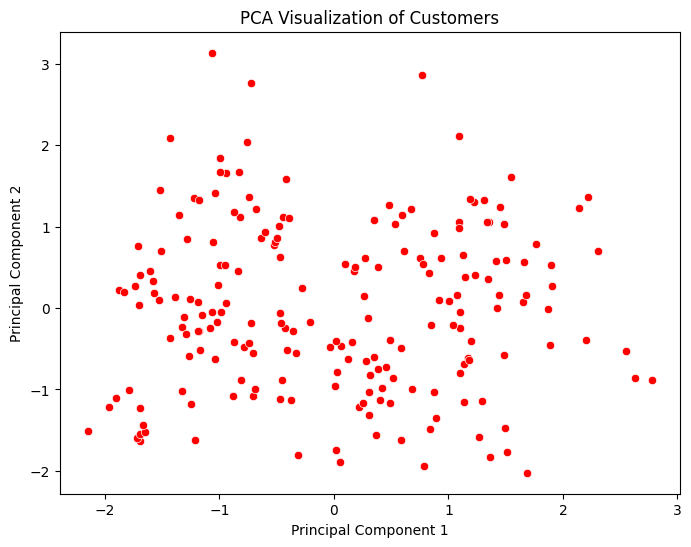

In [11]:
#visualize PCA
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    color='red',
    x='PC1',
    y='PC2')
plt.title("PCA Visualization of Customers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [12]:
#saving the dataset
X_scaled.to_csv("ML_Ready_Dataset.csv", index=False)
print("ML-ready dataset saved successfully!")

ML-ready dataset saved successfully!


In [13]:
from google.colab import drive
drive.mount('/content/drive')

X_scaled.to_csv('/content/drive/MyDrive/ML_Ready_Dataset.csv', index=False)

Mounted at /content/drive
